In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [7]:
df = pd.read_csv("C:/Users/brent/Downloads/recaudacion-tributaria-datos-mensuales.csv")
df.head()

,indice_tiempo,total_recaudacion,subtotal_dgi,subtotal_dga,seguridad_social,total_recaudacion_var_ia,subtotal_dgi_var_ia,subtotal_dga_var_ia,seguridad_social_var_ia
0,1997-01-01,4353.758957,2313.675149,884.341249,1155.742559,NaN,NaN,NaN,NaN
1,1997-02-01,3634.762208,2038.650251,744.108489,852.003468,NaN,NaN,NaN,NaN
2,1997-03-01,3531.360254,1955.433261,799.976108,775.950885,NaN,NaN,NaN,NaN
3,1997-04-01,3939.777343,2154.340531,960.913514,824.523297,NaN,NaN,NaN,NaN
4,1997-05-01,4600.930508,2778.211277,984.078415,838.640816,NaN,NaN,NaN,NaN


In [70]:
df.shape

(338, 9)

In [72]:
df.columns

Index(['indice_tiempo', 'total_recaudacion', 'subtotal_dgi', 'subtotal_dga',
       'seguridad_social', 'total_recaudacion_var_ia', 'subtotal_dgi_var_ia',
       'subtotal_dga_var_ia', 'seguridad_social_var_ia'],
      dtype='object')

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   indice_tiempo             338 non-null    object 
 1   total_recaudacion         338 non-null    float64
 2   subtotal_dgi              338 non-null    float64
 3   subtotal_dga              338 non-null    float64
 4   seguridad_social          338 non-null    float64
 5   total_recaudacion_var_ia  326 non-null    float64
 6   subtotal_dgi_var_ia       290 non-null    float64
 7   subtotal_dga_var_ia       290 non-null    float64
 8   seguridad_social_var_ia   290 non-null    float64
dtypes: float64(8), object(1)
memory usage: 23.9+ KB


In [76]:
# Cuantos valores nulos hay por columna
df.isnull().sum()

indice_tiempo                0
total_recaudacion            0
subtotal_dgi                 0
subtotal_dga                 0
seguridad_social             0
total_recaudacion_var_ia    12
subtotal_dgi_var_ia         48
subtotal_dga_var_ia         48
seguridad_social_var_ia     48
dtype: int64

opción básica y segura es rellenar los valores faltantes con la media (promedio) de cada columna

In [79]:
# Cambiar valores por otros fill(rellenar)
valores_nuevos = {"total_recaudacion_var_ia":df["total_recaudacion_var_ia"].median(), "subtotal_dgi_var_ia":df["subtotal_dgi_var_ia"].median(),"subtotal_dga_var_ia":df["subtotal_dga_var_ia"].median(),"seguridad_social_var_ia":df["seguridad_social_var_ia"].median()}
df_rellenados = df.fillna(valores_nuevos)
df_rellenados.head()

,indice_tiempo,total_recaudacion,subtotal_dgi,subtotal_dga,seguridad_social,total_recaudacion_var_ia,subtotal_dgi_var_ia,subtotal_dga_var_ia,seguridad_social_var_ia
0,1997-01-01,4353.758957,2313.675149,884.341249,1155.742559,0.308446,0.318629,0.34392,0.336157
1,1997-02-01,3634.762208,2038.650251,744.108489,852.003468,0.308446,0.318629,0.34392,0.336157
2,1997-03-01,3531.360254,1955.433261,799.976108,775.950885,0.308446,0.318629,0.34392,0.336157
3,1997-04-01,3939.777343,2154.340531,960.913514,824.523297,0.308446,0.318629,0.34392,0.336157
4,1997-05-01,4600.930508,2778.211277,984.078415,838.640816,0.308446,0.318629,0.34392,0.336157


In [81]:
df_rellenados.isnull().sum()

indice_tiempo               0
total_recaudacion           0
subtotal_dgi                0
subtotal_dga                0
seguridad_social            0
total_recaudacion_var_ia    0
subtotal_dgi_var_ia         0
subtotal_dga_var_ia         0
seguridad_social_var_ia     0
dtype: int64

In [91]:
# Figuras
fig = go.Figure()

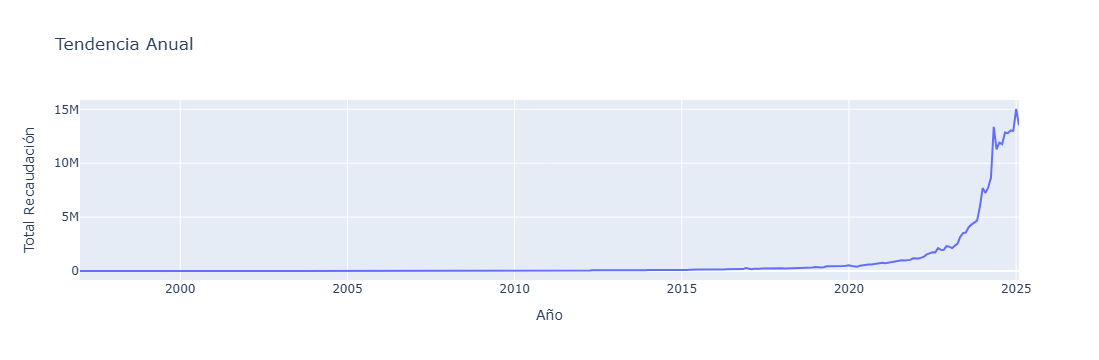

In [93]:
fig.add_trace(go.Scatter(x=df_rellenados["indice_tiempo"],
                       y=df_rellenados["total_recaudacion"],
                       mode='lines',
                       name='Total'))
fig.update_layout(go.Layout(
            title='Tendencia Anual',
            xaxis = dict(title = 'Año'),
            yaxis = dict(title = 'Total Recaudación')
))

In [103]:
fig = go.Figure()

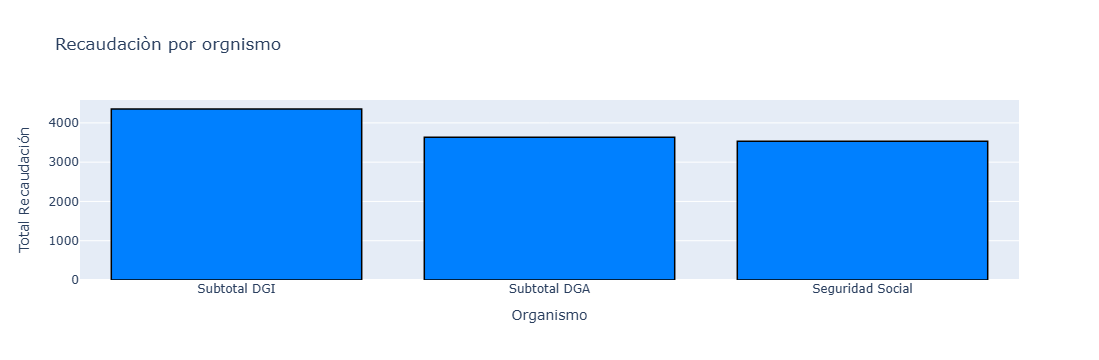

In [105]:
fig.add_trace(go.Bar(x=["Subtotal DGI", "Subtotal DGA", "Seguridad Social"],
                        y=df_rellenados["total_recaudacion"],
                       marker=dict(
                           color='rgb(0,128,255,.6)',
                           line=dict(color='rgb(0,0,0)',
                            width=1.5))))
fig.update_layout(go.Layout(
            title='Recaudaciòn por orgnismo',
            xaxis = dict(title = 'Organismo'),
            yaxis = dict(title = 'Total Recaudación')
))

In [115]:
figTorta = go.Figure()

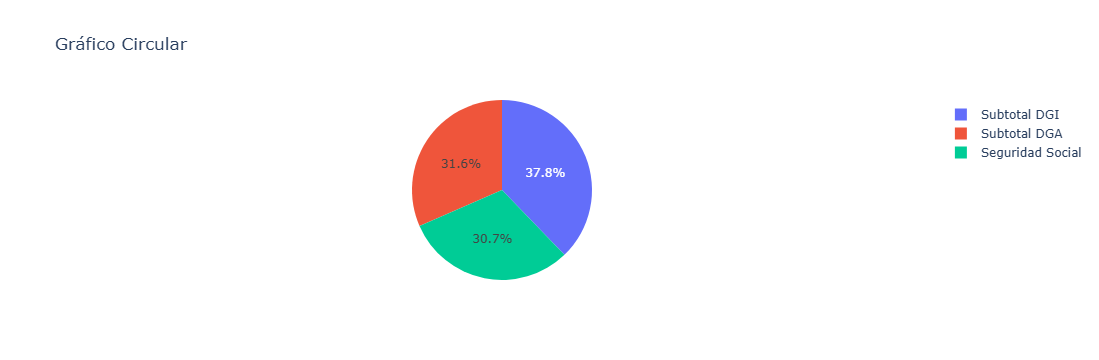

In [117]:
figTorta.add_trace(go.Pie(
    labels=["Subtotal DGI", "Subtotal DGA", "Seguridad Social"],
    values=df_rellenados["total_recaudacion"]
))
figTorta.update_layout(go.Layout(
            title='Gráfico Circular'
))

In [119]:
# Convertir la columna de fechas a formato datetime
df_rellenados["indice_tiempo"] = pd.to_datetime(df_rellenados["indice_tiempo"])

# Obtener el año actual
anio_actual = pd.Timestamp.today().year

# Filtrar los últimos 5 años
df_ultimos_5_anios = df_rellenados[df_rellenados["indice_tiempo"].dt.year >= (anio_actual - 5)]

# Mostrar los primeros registros del nuevo dataset
df_ultimos_5_anios.head()

,indice_tiempo,total_recaudacion,subtotal_dgi,subtotal_dga,seguridad_social,total_recaudacion_var_ia,subtotal_dgi_var_ia,subtotal_dga_var_ia,seguridad_social_var_ia
276,2020-01-01,527284.462170,275334.296334,100924.092322,151026.073514,0.448874,0.407278,0.705510,0.384273
277,2020-02-01,471693.290156,268560.515196,80596.600175,122536.174785,0.425526,0.411571,0.469387,0.428430
278,2020-03-01,443636.656183,228462.311970,95245.179489,119929.164725,0.353088,0.265394,0.545402,0.399538
279,2020-04-01,398658.723755,208231.274870,90007.279974,100420.168910,0.115559,0.073505,0.248367,0.100024
280,2020-05-01,499534.963120,303294.271123,94992.401783,101248.290215,0.124446,0.229311,-0.110890,0.116409


In [125]:
# Figuras
figAnios = go.Figure()

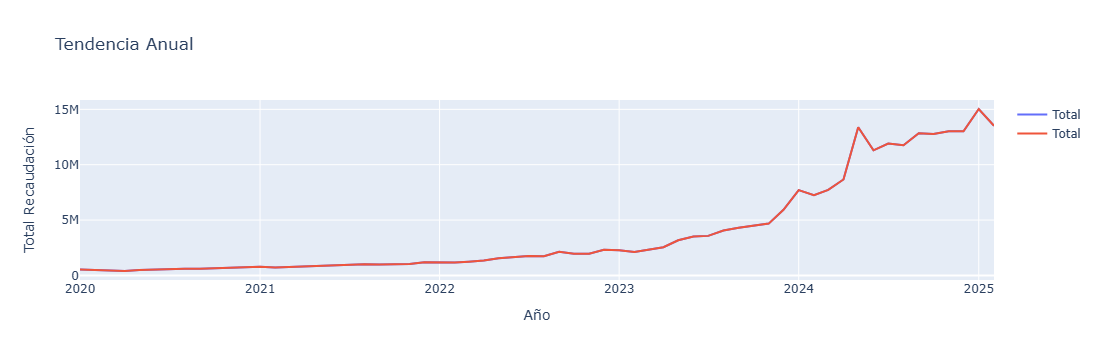

In [129]:
figAnios.add_trace(go.Scatter(x=df_ultimos_5_anios["indice_tiempo"],
                       y=df_ultimos_5_anios["total_recaudacion"],
                       mode='lines',
                       name='Total'))
figAnios.update_layout(go.Layout(
            title='Tendencia Anual',
            xaxis = dict(title = 'Año'),
            yaxis = dict(title = 'Total Recaudación')
))

In [19]:
# Convertir la columna de fechas a formato datetime
df["indice_tiempo"] = pd.to_datetime(df["indice_tiempo"])

# Extraer el año
df["Año"] = df["indice_tiempo"].dt.year

# Filtrar los últimos 3 años
ultimos_tres_anios = sorted(df["Año"].unique())[-4:]
df_ultimos_4_anios = df[df["Año"].isin(ultimos_tres_anios)]

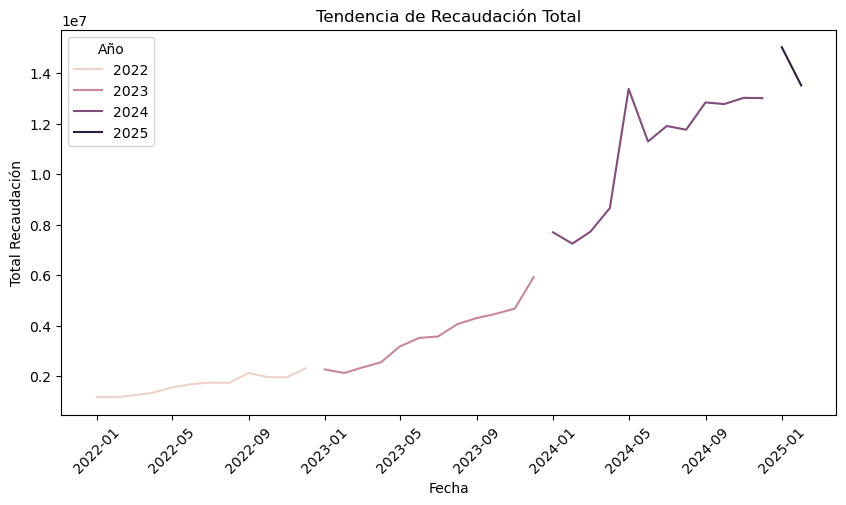

In [23]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_ultimos_4_anios, x="indice_tiempo", y="total_recaudacion", hue="Año")
plt.title("Tendencia de Recaudación Total")
plt.xlabel("Fecha")
plt.ylabel("Total Recaudación")
plt.xticks(rotation=45)
plt.show()

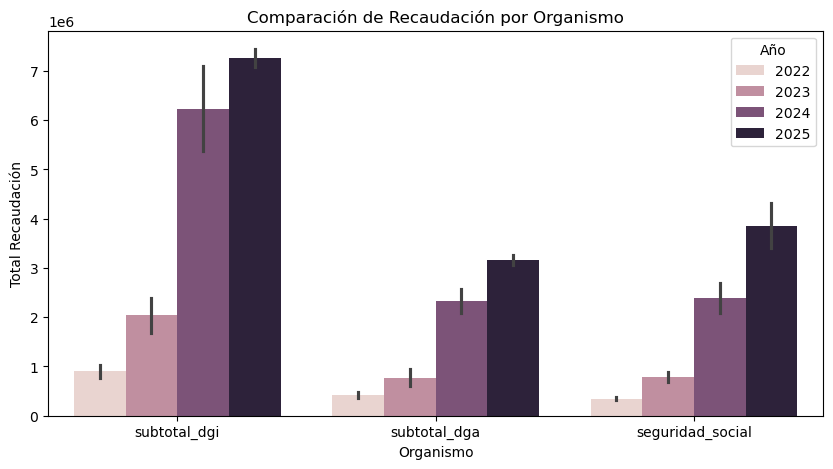

In [25]:
df_melted = df_ultimos_4_anios.melt(id_vars=["Año"], value_vars=["subtotal_dgi", "subtotal_dga", "seguridad_social"],
                                    var_name="Organismo", value_name="Recaudación")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x="Organismo", y="Recaudación", hue="Año")
plt.title("Comparación de Recaudación por Organismo")
plt.xlabel("Organismo")
plt.ylabel("Total Recaudación")
plt.show()

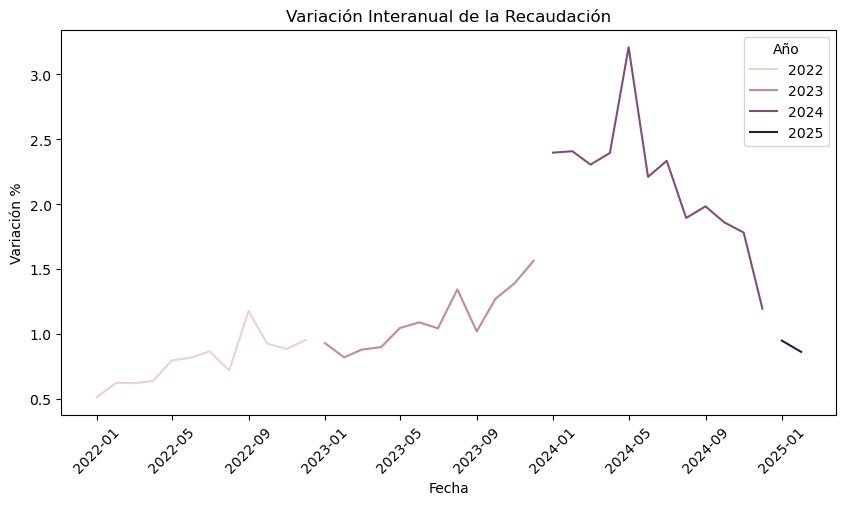

In [27]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_ultimos_4_anios, x="indice_tiempo", y="total_recaudacion_var_ia", hue="Año")
plt.title("Variación Interanual de la Recaudación")
plt.xlabel("Fecha")
plt.ylabel("Variación %")
plt.xticks(rotation=45)
plt.show()

C:\Users\brent\AppData\Local\Temp\ipykernel_11688\2437423349.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ultimos_3_anios["Mes"] = df_ultimos_3_anios["indice_tiempo"].dt.month


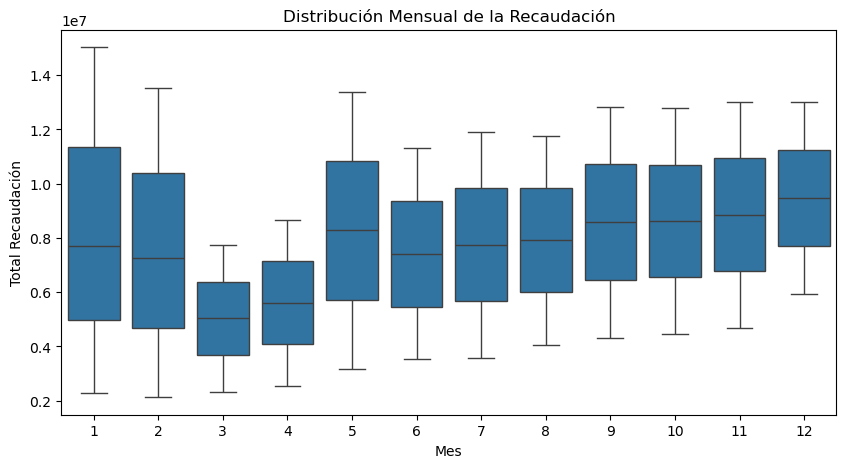

In [17]:
df_ultimos_3_anios["Mes"] = df_ultimos_3_anios["indice_tiempo"].dt.month

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_ultimos_3_anios, x="Mes", y="total_recaudacion")
plt.title("Distribución Mensual de la Recaudación")
plt.xlabel("Mes")
plt.ylabel("Total Recaudación")
plt.show()
